# Fit.ly Subscriber Churn Analysis

A data validation and exploratory churn analysis for a fitness subscription app, joining account, support, and in-app activity data to identify what's driving churn and to propose a KPI the business can act on.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', None)

acc = pd.read_csv('data/da_fitly_account_info.csv')
sup = pd.read_csv('data/da_fitly_customer_support.csv')
act = pd.read_csv('data/da_fitly_user_activity.csv')

print(acc.shape, sup.shape, act.shape)

(400, 6) (918, 7) (445, 3)


## Data Validation

Before any analysis, I checked every column in all three files against what the Product Manager and Lead Engineer described, and against basic sanity checks (nulls, duplicates, ranges, valid categories). I cross-referenced customer IDs across all three tables to confirm they could be joined reliably.

In [15]:
print("Account info - nulls:\n", acc.isna().sum(), "\n")
print("Customer support - nulls:\n", sup.isna().sum(), "\n")
print("User activity - nulls:\n", act.isna().sum(), "\n")

print("Duplicate rows:", acc.duplicated().sum(), sup.duplicated().sum(), act.duplicated().sum())
print("Plan categories:", acc.plan.unique())
print("Churn values:", acc.churn_status.unique())
print("Support channel values:", sup.channel.unique())
print("Support state values:", sup.state.unique())

Account info - nulls:
 customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64 

Customer support - nulls:
 ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64 

User activity - nulls:
 event_time    0
user_id       0
event_type    0
dtype: int64 

Duplicate rows: 0 0 0
Plan categories: ['Enterprise' 'Basic' 'Free' 'Pro']
Churn values: ['Y' nan]
Support channel values: ['chat' 'phone' '-' 'email']
Support state values: [1 0]


**customer_id / email** — No nulls, no duplicates, valid email format, and every email's number matches its `customer_id`. Treated as a reliable key; stripped the "C" prefix to get a numeric `user_id` for joining to the other two tables (all 400 IDs matched cleanly with no orphans).

**state** — 50 valid US state names, no nulls or typos, consistent with the PM's note that Fit.ly is US-only.

**plan** — Exactly four values (Free, Basic, Pro, Enterprise), matching the PM's expected tiers. No nulls or inconsistent casing.

**plan_list_price** — No nulls, no negative values. Price varies *within* each plan tier (e.g. Basic ranges $10–$30), which makes sense given the PM described this field as the *actual price paid*, not a fixed list price — likely reflecting discounts/promotions. The column name is a bit misleading given that description, but the values themselves are internally consistent: $0 only for Free, and tier ranges never overlap (Basic max $30 < Pro min $32 < Enterprise min $81), which is a good sign the data isn't corrupted.

**churn_status** — Only two values appear: `'Y'` and missing. Based on the PM's description ("we mark people as churned once cancelled" — implying the flag is only *set* on a churn event), I treated missing as **not churned** rather than as missing data, and created a clean binary `churned` column (1/0). This is an inference, not an explicit confirmation from the PM, so I've flagged it as a decision to sign off on. Resulting baseline churn rate: **28.5%** (114 of 400 customers).

**Data gap to flag:** the PM's email describes a `signup_date` field ("the day the customer created their account"), but it does not exist in the file we received. This means we can't analyze churn by customer tenure or cohort — recommend this gets added to the export.

**ticket_time** — Parses cleanly as a datetime, no nulls. Per the PM, this is captured in Pacific time. Range: June–December 2025, no implausible future dates.

**user_id** — No nulls. Every support `user_id` matches an existing `customer_id` in account_info — no orphaned tickets.

**channel** — Three valid values (chat, email, phone) plus 39 rows (4.2%) using `"-"` as a placeholder for missing. Recoded these to a proper missing value rather than treating "-" as its own category.

**topic** — Four categories (billing, account, technical, other), fairly evenly split, no nulls or invalid values.

**resolution_time_hours** — No nulls, no zero or negative values, computed upstream in ETL per the Lead Engineer. Range (0.5–32.5 hrs) looks reasonable with no extreme outliers.

**state** — This column name overlaps with account_info's "state" (US state) but holds only binary 0/1 values, and its meaning was never defined by either stakeholder. I checked it against resolution time, topic, and channel and found no meaningful pattern in any of them — so rather than guess, I've parked this column out of the analysis and flagged it as a question for Engineering.

**comments** — 95% empty. Of the 46 populated rows, **100% are GDPR "right to be forgotten" / data-erasure requests** (e.g. "Erase my data from your systems," "Requesting right to be forgotten"). This is a compliance-sensitive finding: these requests are currently surfacing informally inside a free-text support field rather than through a proper intake process. I created a binary `has_gdpr_request` flag for visibility, but did **not** use it as a churn-driver feature — treating a legal erasure request as a "retention opportunity" would be inappropriate. This is called out separately as an action item for Legal/Compliance, not as a marketing insight.

No exact duplicate tickets were found anywhere in the file.

**event_time** — Parses cleanly, no nulls, same June–December 2025 window as support data.

**user_id** — No nulls, every ID matches an account in account_info.

**event_type** — Four valid categories (watch_video, read_article, track_workout, share_workout), reasonably balanced, no nulls or invalid values.

One caveat worth noting: only 246 of 400 customers (61.5%) have *any* logged activity event in this ~6-month window, and total volume is low (445 events across 400 customers). This activity log appears to capture specific in-app actions rather than every app open, so absolute engagement levels should be read with that in mind — but the *relative* comparison between high- and low-activity customers (which is what drives the findings below) is still a strong, valid signal.

In [16]:
acc['user_id'] = acc['customer_id'].str.replace('C', '', regex=False).astype(int)
acc['plan'] = acc['plan'].str.strip().str.title()
acc['churned'] = np.where(acc['churn_status'] == 'Y', 1, 0)

sup['ticket_time'] = pd.to_datetime(sup['ticket_time'])
sup['channel'] = sup['channel'].replace('-', np.nan)
sup['has_gdpr_request'] = sup['comments'].notna().astype(int)

act['event_time'] = pd.to_datetime(act['event_time'])

print("Churn rate:", acc['churned'].mean())

Churn rate: 0.285


## Combining the data

To analyze engagement, support activity, and plan together, I aggregated the support and activity logs to one row per customer and joined everything onto `account_info`.

In [17]:
snapshot_date = max(sup.ticket_time.max(), act.event_time.max())

sup_agg = sup.groupby('user_id').agg(
    n_tickets=('ticket_time', 'count'),
    avg_resolution_hrs=('resolution_time_hours', 'mean'),
    n_gdpr_requests=('has_gdpr_request', 'sum'),
).reset_index()

act_agg = act.groupby('user_id').agg(
    n_events=('event_time', 'count'),
).reset_index()

master = acc.merge(sup_agg, on='user_id', how='left').merge(act_agg, on='user_id', how='left')
master[['n_tickets', 'n_gdpr_requests', 'n_events']] = master[['n_tickets', 'n_gdpr_requests', 'n_events']].fillna(0)

def eng_bucket(n):
    if n == 0: return '0 events'
    elif n <= 2: return '1-2 events'
    else: return '3+ events'
master['engagement_bucket'] = master['n_events'].apply(eng_bucket)

active_30d_ids = act[act.event_time >= snapshot_date - pd.Timedelta(days=30)].user_id.unique()
master['active_30d'] = master.user_id.isin(active_30d_ids).astype(int)

master.head()

,customer_id,email,state,plan,plan_list_price,churn_status,user_id,churned,n_tickets,avg_resolution_hrs,n_gdpr_requests,n_events,engagement_bucket,active_30d
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y,10000,1,3.0,21.446667,0.0,3.0,3+ events,1
1,C10001,user10001@example.net,Louisiana,Basic,22,Y,10001,1,4.0,17.542500,0.0,1.0,1-2 events,0
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN,10002,0,3.0,6.433333,0.0,1.0,1-2 events,0
3,C10003,user10003@example.com,Michigan,Free,0,NaN,10003,0,1.0,2.190000,0.0,1.0,1-2 events,0
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN,10004,0,4.0,8.542500,0.0,4.0,3+ events,0


## Exploratory Analysis

I focused this on the three areas the business asked for: engagement, support activity, and plan type, alongside their relationship to churn.

In [ ]:
plan_order = ['Free', 'Basic', 'Pro', 'Enterprise']
counts = master['plan'].value_counts().reindex(plan_order)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(counts.index, counts.values, color=['#9aa5b1', '#2a9d8f', '#1f3a5f', '#e9c46a'])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3, f'{int(b.get_height())}',
            ha='center', fontweight='bold')
ax.set_title('Subscribers by Plan Type', fontweight='bold', loc='left')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(master['n_events'], bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5,6.5], color='#1f3a5f', rwidth=0.85)
ax.set_title('Distribution of In-App Activity Events per Customer', fontweight='bold', loc='left')
ax.set_xlabel('Number of logged activity events (6-month window)')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

**Findings (single-variable):** Plan distribution skews toward Basic and Free (118 and 105 customers respectively), with Pro and Enterprise smaller (85 and 92). Activity is heavily right-skewed: 154 of 400 customers (38.5%) logged **zero** activity events in the period, while a smaller group logged 3 or more — engagement is concentrated in a minority of the base.

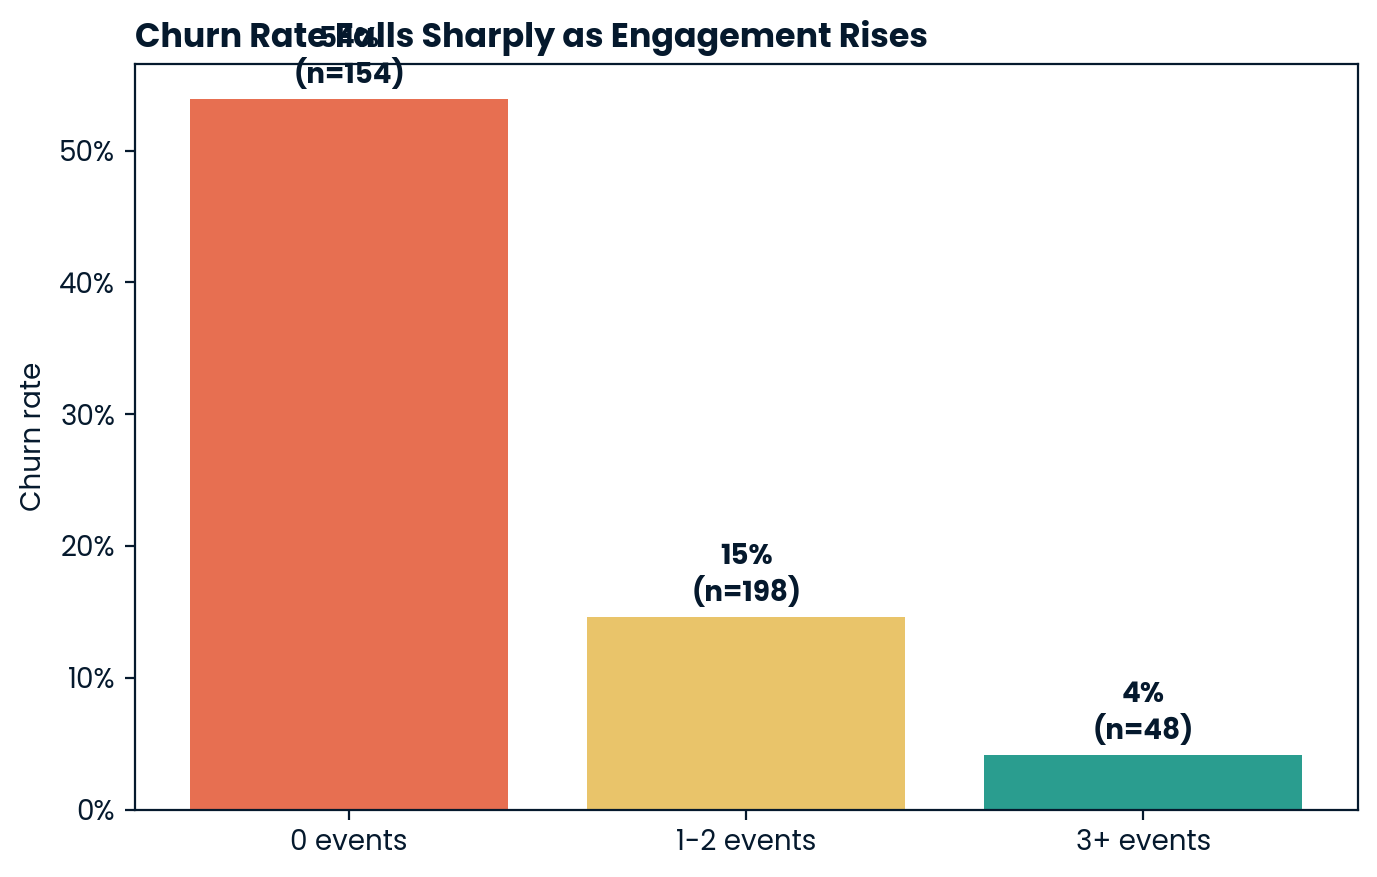

In [18]:
order = ['0 events', '1-2 events', '3+ events']
g = master.groupby('engagement_bucket')['churned'].mean().reindex(order)
n = master.groupby('engagement_bucket')['churned'].count().reindex(order)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(g.index, g.values, color=['#e76f51', '#e9c46a', '#2a9d8f'])
for b, ni in zip(bars, n.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012, f'{b.get_height():.0%}\n(n={ni})',
            ha='center', fontweight='bold')
ax.set_title('Churn Rate Falls Sharply as Engagement Rises', fontweight='bold', loc='left')
ax.set_ylabel('Churn rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

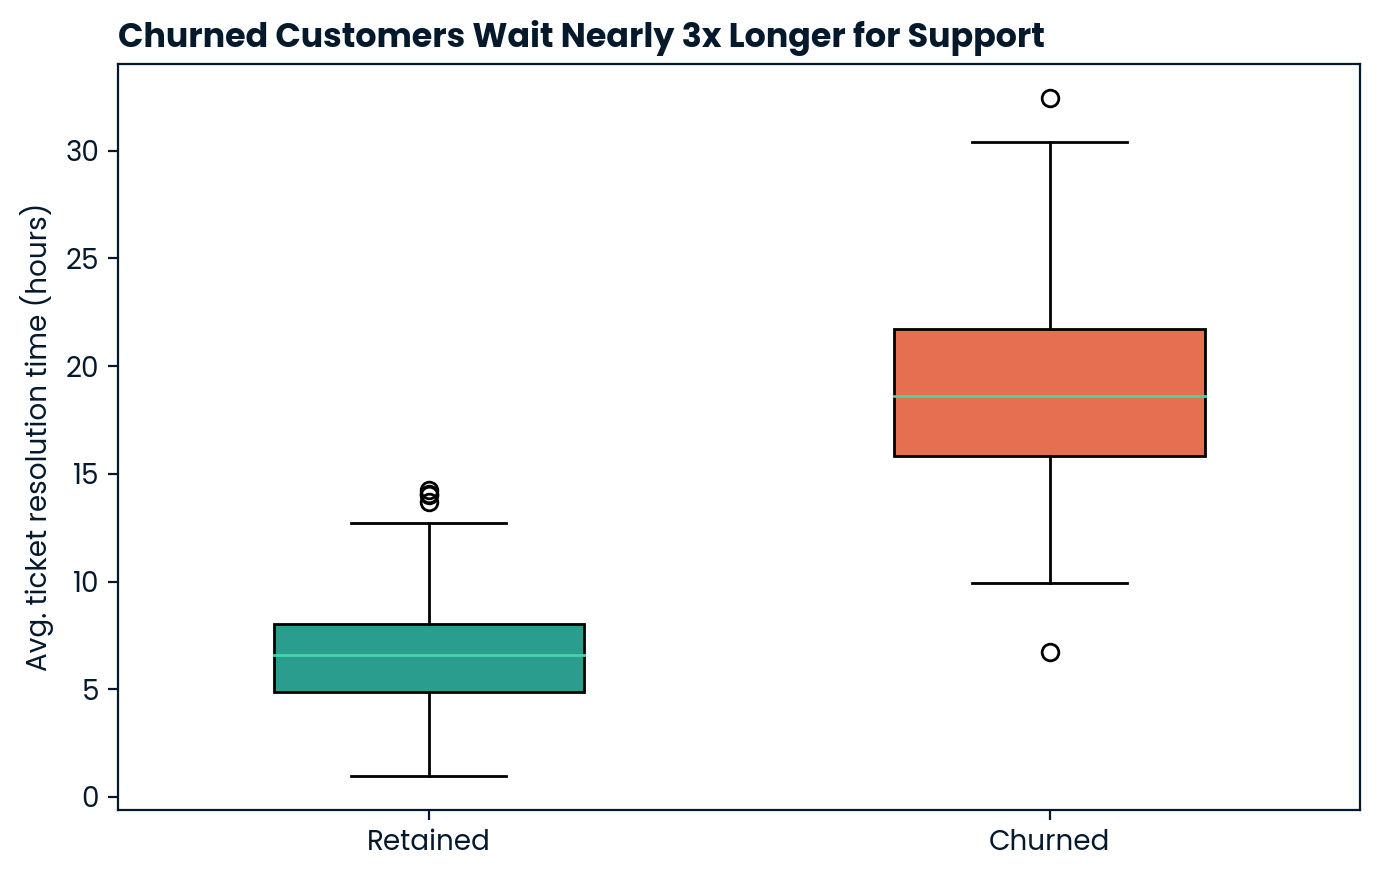

In [23]:
sup_users = master[master.n_tickets > 0]
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [sup_users[sup_users.churned==0]['avg_resolution_hrs'], sup_users[sup_users.churned==1]['avg_resolution_hrs']]
bp = ax.boxplot(data, labels=['Retained', 'Churned'], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ['#2a9d8f', '#e76f51']):
    patch.set_facecolor(color)
ax.set_title('Churned Customers Wait Nearly 3x Longer for Support', fontweight='bold', loc='left')
ax.set_ylabel('Avg. ticket resolution time (hours)')
plt.tight_layout()
plt.show()

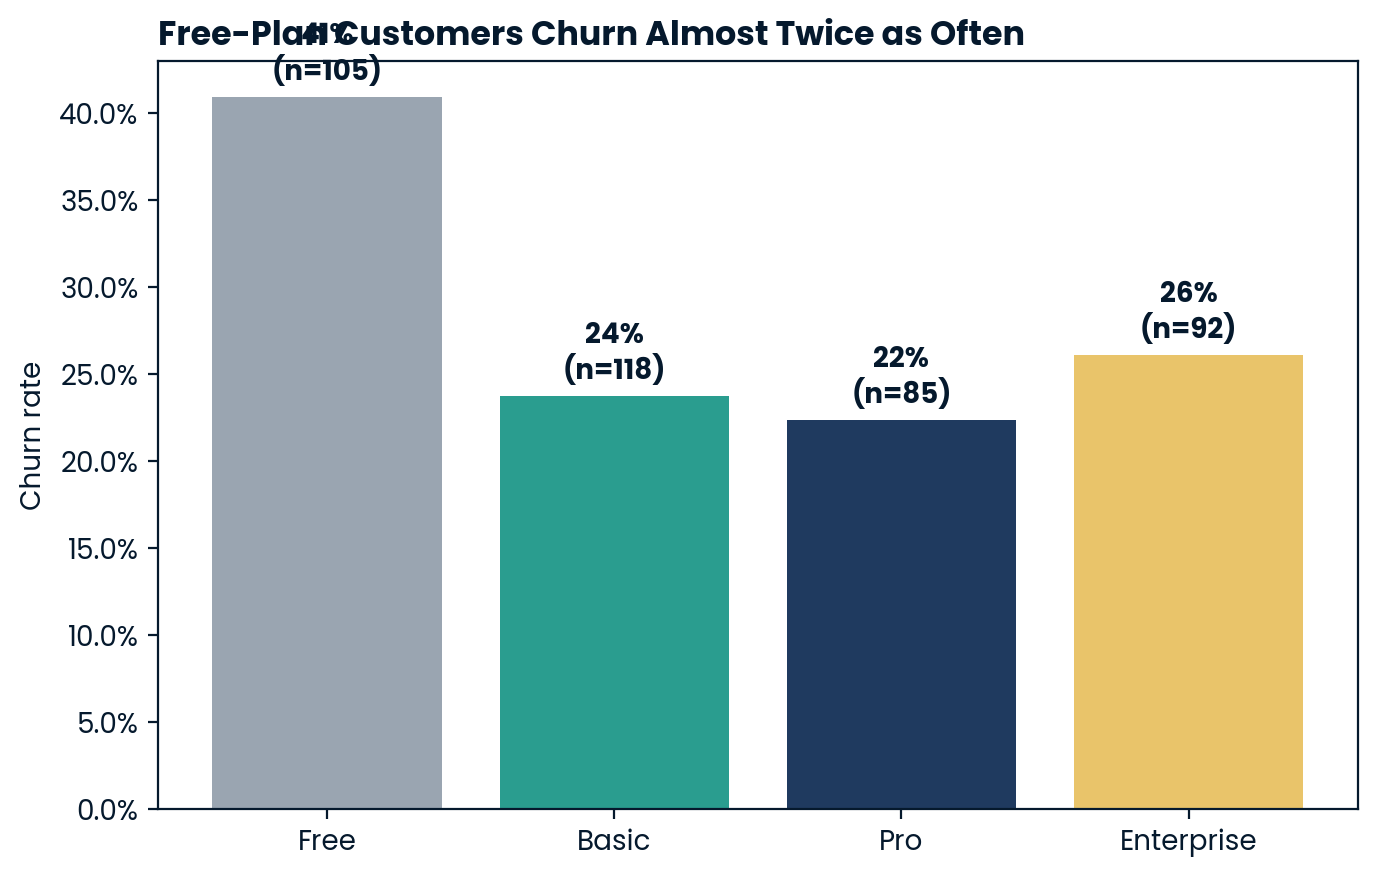

In [21]:
plan_order = ['Free', 'Basic', 'Pro', 'Enterprise']

g2 = master.groupby('plan')['churned'].mean().reindex(plan_order)
n2 = master.groupby('plan')['churned'].count().reindex(plan_order)
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(g2.index, g2.values, color=['#9aa5b1', '#2a9d8f', '#1f3a5f', '#e9c46a'])
for b, ni in zip(bars, n2.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.0%}\n(n={ni})',
            ha='center', fontweight='bold')
ax.set_title('Free-Plan Customers Churn Almost Twice as Often', fontweight='bold', loc='left')
ax.set_ylabel('Churn rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

**Findings (multi-variable):**

- **Engagement is the strongest churn signal in the data.** Customers with zero logged activity churn at 54%, versus 15% for those with 1-2 events and just 4% for those with 3+ events — more than a 12x spread between the least and most engaged groups.
- **Support resolution speed tracks closely with churn.** Among customers who contacted support, churned customers waited 18.7 hours on average for a resolution, versus 6.7 hours for retained customers — nearly 3x longer, with very little overlap between the two distributions. Interestingly, the *number* of tickets a customer raised was only weakly related to churn (28-31% across 1, 2, or 3+ tickets) — it's resolution speed, not contact volume, that matters.
- **Free-plan customers churn almost twice as often as paid customers** (41% vs. 22-26%), and they're also the least engaged plan tier on average (0.93 events vs. 1.0-1.3 for paid tiers) — these two findings reinforce each other.

## Metric to Monitor: 30-Day Engagement Rate

**Definition:** the percentage of subscribers who log at least one in-app activity event (watch video, track workout, share workout, read article) in a trailing 30-day window.

**Why this metric:** of everything tested, engagement was the strongest and most actionable churn signal — and unlike churn itself, it's a *leading* indicator the business can act on before a customer cancels, rather than a lagging one that only confirms the loss after the fact.

**How the business should use it:** track it monthly, both overall and broken out by plan tier, and treat 30 days of inactivity as a trigger point for an automatic re-engagement touchpoint (push notification, email, etc.) rather than waiting for a cancellation.

**Current baseline, estimated from this data:**

30-Day Engagement Rate (baseline): 17.2%
Churn rate, NOT active in last 30 days: 32.6%
Churn rate, active in last 30 days:     8.7%


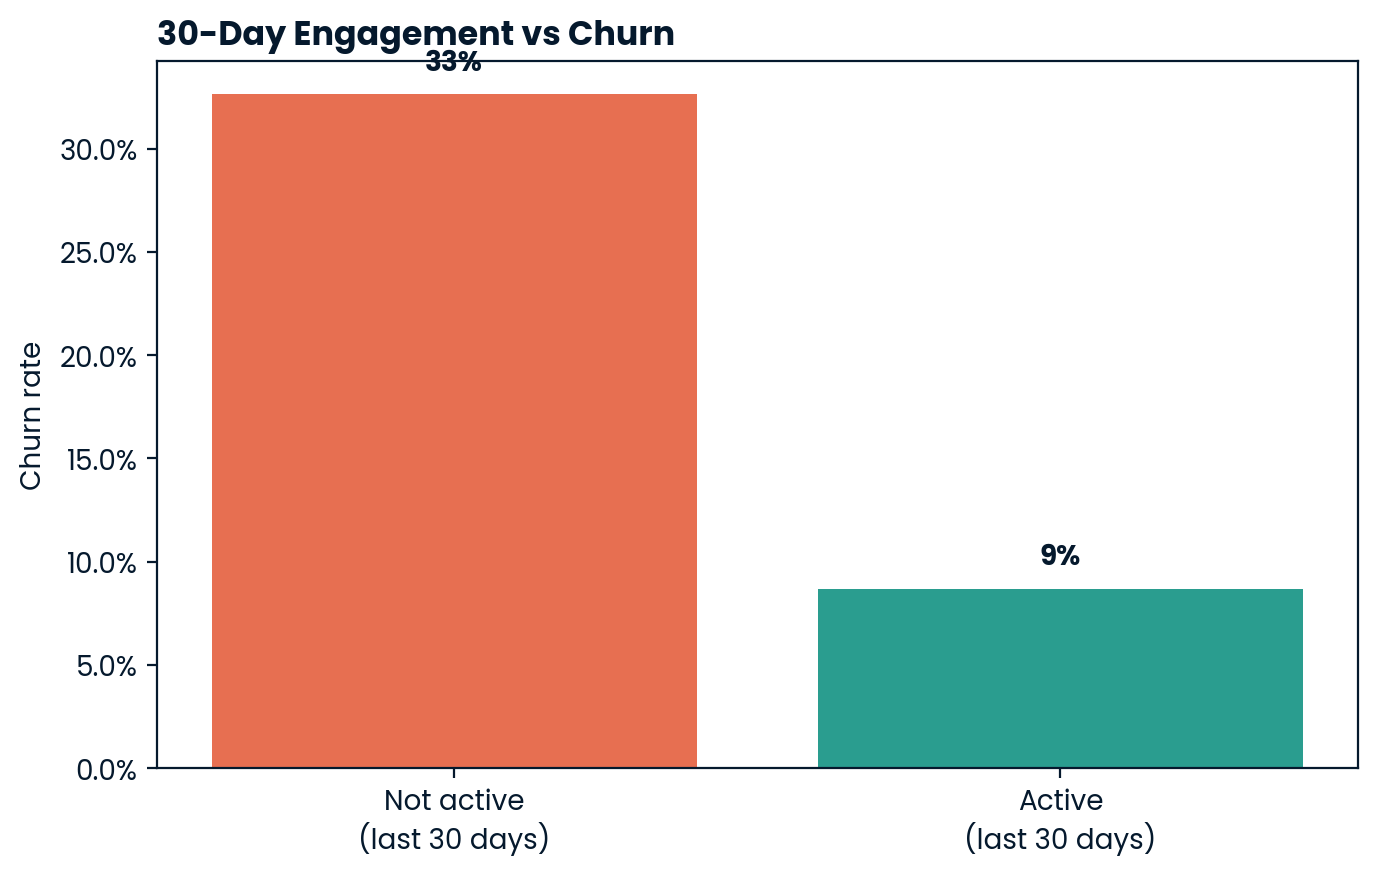

In [13]:
engagement_rate_30d = master['active_30d'].mean()
churn_by_30d = master.groupby('active_30d')['churned'].mean()

print(f"30-Day Engagement Rate (baseline): {engagement_rate_30d:.1%}")
print(f"Churn rate, NOT active in last 30 days: {churn_by_30d[0]:.1%}")
print(f"Churn rate, active in last 30 days:     {churn_by_30d[1]:.1%}")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(['Not active\n(last 30 days)', 'Active\n(last 30 days)'],
               [churn_by_30d[0], churn_by_30d[1]], color=['#e76f51', '#2a9d8f'])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012, f'{b.get_height():.0%}', ha='center', fontweight='bold')
ax.set_title('30-Day Engagement vs Churn', fontweight='bold', loc='left')
ax.set_ylabel('Churn rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

**Baseline:** the current 30-Day Engagement Rate is **17.2%** (69 of 400 customers). This is a useful starting point precisely because it's so predictive: customers active in the last 30 days churn at **8.7%**, while inactive customers churn at **32.6%** — a near 4x gap. Raising this baseline is the clearest lever available to bring overall churn down.

## Final Summary & Recommendations

**The business problem:** churn currently sits at 28.5% — over a quarter of subscribers in this dataset have cancelled. This analysis set out to identify what's driving that, specifically across engagement, support experience, and plan type, as requested.

**What we found:** churn is not evenly distributed — it's concentrated in three overlapping groups: customers with no in-app engagement, customers who experience slow support resolution, and Free-plan customers (who tend to be the least engaged of all). These three findings reinforce each other rather than being independent drivers.

**Recommendations:**

1. **Trigger re-engagement outreach at 30 days of inactivity.** This is the single highest-leverage group: 38.5% of the base, churning at 54%. A push notification, email check-in, or personalized workout prompt at this threshold directly targets the strongest signal in the data.
2. **Set a support resolution SLA (e.g. 8 business hours).** Resolution speed — not ticket volume — is what separates churned from retained customers among those who contact support. Investing in support capacity/triage is likely to pay off disproportionately.
3. **Build a structured Free-to-paid upgrade path.** Free customers churn at nearly double the rate of paid tiers. Engagement-triggered upgrade offers (e.g. to active Free users) could convert at-risk free customers before they lapse entirely.
4. **Formalize GDPR/data-erasure request handling.** These requests are currently surfacing informally inside support comments (46 tickets, ~11% of customers) rather than through a proper compliance channel — this is a process gap that should be closed with Legal, independent of the churn work.
5. **Adopt 30-Day Engagement Rate as a standing KPI**, tracked monthly and by plan, starting from today's baseline of 17.2%.

**Open items for follow-up:** `signup_date` was referenced by the Product Manager but isn't present in the account data — recommend adding it to enable tenure/cohort analysis. A binary `state` field in the support data is undocumented and showed no usable pattern — flagged for Engineering rather than guessed at.